# Aprendizaje Profundo
## Tarea 2: Redes convolucionales y transferencia
### Eduardo García Alarcón - PCIC
#### Ejercicio 3 - Reconocimiento Comandos de Voz

Compara modelos basados en redes recurrentes y convolucionales para el reconocimiento de comandos de voz usando el conjunto de Speech Commands. En particular deberás:

- Entrenar y evaluar un modelo basado en capas convolucionales 1D
- Entrenar y evaluar un modelo basado en capas convolucionales 2D
- Graficar las pérdidas y métricas de entrenamiento y validación y discutir todos los resultados

En todos los casos, se deberán representar los comandos de voz mediante espectogramas Mel, Mel-log o MFCCs.

In [1]:
# Bibliotecas 図書館
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import pandas as pd

import torch as th
from torch import nn

# Por reproducibilidad
th.manual_seed(42)
np.random.seed(42)

LOGDIR = './logs/'
DC     = 'cuda:0' if th.cuda.is_available() else 'cpu'

In [2]:
# tomar n elementos de una secuencia
from itertools import islice as take

# audio
import librosa
import librosa.display
import IPython as ip

# redes audio
import torchaudio
import torchaudio.transforms as T
# redes visión
import torchvision.models as tv

# redes neuronales
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

# barras de progreso
from tqdm.auto import trange

#Counter
import collections

# Files
from os.path import join

/home/qweryedu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATADIR = './'

In [4]:
ds = SPEECHCOMMANDS(DATADIR, download=True)

### Escuchamos un ejemplo

In [5]:
waveform, sample_rate, label, id_spk, utt = ds[3078]

print(
    f'Etiqueta: {label}\n'
    f'Forma de onda: {waveform.shape}\n'
    f'Frecuencia de muestreo: {sample_rate}\n'
    f'Duración: {waveform.shape[1] / sample_rate}\n'
    f'Tipo: {waveform.dtype}\n'
)

Etiqueta: bed
Forma de onda: torch.Size([1, 14861])
Frecuencia de muestreo: 16000
Duración: 0.9288125
Tipo: torch.float32



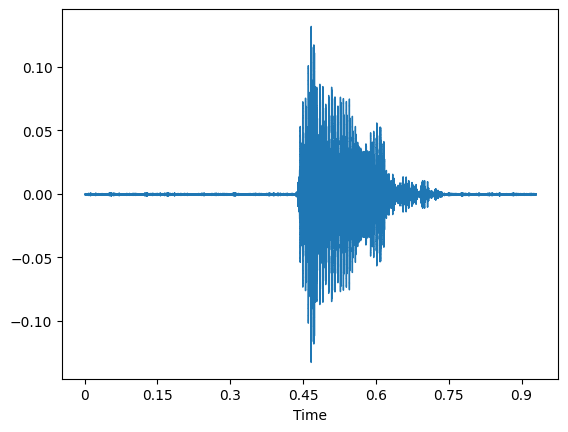

In [6]:
librosa.display.waveshow(waveform.flatten().numpy(), sr=sample_rate)

#### Hyper parámetros
Definimos el tamaño de ventana de la FFT, que es la resolución frecuencial

Y el tamaño de sobrelape que tiene nuetra ventana de muestreo; en este caso vamos a querer que sea un traslape de la mitad de la ventana

In [7]:
# Tamaño de la ventana
window_size = 1000
# Tamaño de traslape
hop_length = window_size // 2


#### Se usarán los MFCCs para esta tarea

In [8]:
MFCC = T.MFCC()

/home/qweryedu/.local/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


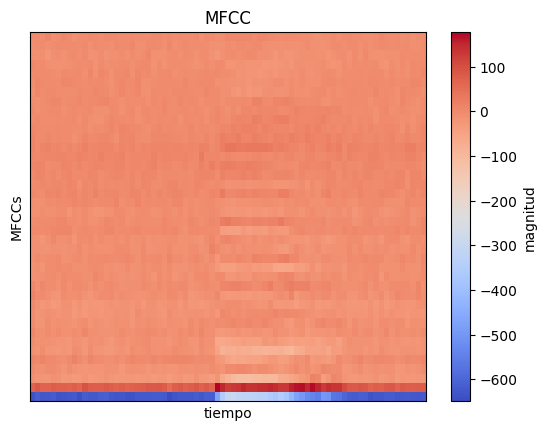

In [9]:
mfccs_numpy = MFCC(waveform).squeeze().numpy()

librosa.display.specshow(mfccs_numpy, sr=sample_rate, hop_length=hop_length)
plt.title('MFCC')
plt.xlabel('tiempo')
plt.ylabel('MFCCs')
cbar = plt.colorbar()
cbar.set_label('magnitud', rotation=90)
plt.show()

### Conjunto de datos

In [10]:
# Tamaño de lote
BATCH_SIZE = 64

# Audio Params
SECS = 1
SAMPLE_RATE = 16000

# FFT Params
N_FFT = 400
HOP_LENGHT = N_FFT//2

# SpeechCommands classes
CLASSES = (
    'backward', 'bed', 'bird', 'cat', 'dog',
    'down', 'eight', 'five', 'follow', 'forward',
    'four', 'go', 'happy', 'house', 'learn',
    'left', 'marvin', 'nine', 'no', 'off',
    'on', 'one', 'right', 'seven', 'sheila',
    'six', 'stop', 'three', 'tree', 'two',
    'up', 'visual', 'wow', 'yes', 'zero'
)

NUM_CLASSES = len(CLASSES)
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASS_IDX)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


In [11]:

def identity(x):
  return x


def label2index(label):
  return CLASS_IDX[label]


class SPEECHCOMMANDS2(SPEECHCOMMANDS):

  def __init__(self, root, download=False, subset=None,
               waveform_tsfm=identity, label_tsfm=identity):
      
      super().__init__(root=root, download=download, subset=subset)

      self.waveform_tsfm = waveform_tsfm
      self.label_tsfm = label_tsfm

  def __getitem__(self, i):
    waveform, sample_rate, label, *_ = super().__getitem__(i)
    x = self.waveform_tsfm(waveform)
    y = self.label_tsfm(label)
    return x, y, label, sample_rate

In [12]:
class WaveformPadTruncate(nn.Module):

  def __init__(self, secs=SECS, sample_rate=SAMPLE_RATE):
    super().__init__()
    self.samples = secs * sample_rate

  def forward(self, waveform):
    samples = waveform.shape[1]

    if samples < self.samples:
      difference = self.samples - samples
      padding = th.zeros(1, difference)
      waveform = th.cat([waveform, padding], 1)

    elif samples > self.samples:
      start = np.random.randint(0, waveform.shape[1] - self.samples)
      # Devuelve un nuevo tensor que es una versión reducida del tensor de entrada.
      waveform = waveform.narrow(1, start, self.samples) # (dimension, start, length)

    return waveform

    #start = random.randint(0, waveform.shape[1] - self.samples)
    #waveform = waveform.narrow(1, start, self.samples)
    #return waveform

In [13]:
# creamos un Dataset
ds = SPEECHCOMMANDS2(
    # directorio de datos
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=WaveformPadTruncate(),
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)

In [14]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }, {sr=}')

x shape=torch.Size([64, 1, 16000]) dtype=torch.float32
y shape=torch.Size([64]) dtype=torch.int64
labels = ('down', 'no', 'five', 'one', 'three', 'six', 'left', 'zero', 'on', 'six', 'happy', 'five', 'nine', 'nine', 'cat', 'zero', 'on', 'seven', 'left', 'right', 'yes', 'off', 'yes', 'six', 'one', 'one', 'six', 'follow', 'stop', 'no', 'sheila', 'bird', 'seven', 'forward', 'left', 'on', 'five', 'yes', 'two', 'marvin', 'forward', 'go', 'tree', 'stop', 'down', 'nine', 'off', 'on', 'up', 'up', 'one', 'nine', 'one', 'two', 'wow', 'three', 'seven', 'bird', 'three', 'off', 'one', 'house', 'eight', 'nine'), sr=tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
  

In [15]:
CLASS_IDX.get('four')

10

### Redes Neuronales

#### Red 1D

In [119]:
class Red1D(nn.Module):
  def __init__(self, input_size, num_clases, sr=16000):
    super(Red1D, self).__init__()
    self.input_size = input_size
    self.num_clases = num_clases
    self.sr = sr

    self.data_aug = T.TimeMasking(sr//4)
    self.conv1 = nn.Conv1d(input_size, input_size//4, 40)
    self.maxPool = nn.MaxPool1d(4)
    self.conv2 = nn.Conv1d(input_size//4,input_size//16, 3 )
    self.globAvgPool = nn.MaxPool1d(1)
    self.fc = nn.Linear(1, num_clases)

  def forward(self, x):
    x = self.data_aug(x)
    x = self.conv1(x)
    x = self.maxPool(x)
    x = self.conv2(x)
    x = self.maxPool(x)
    x = self.globAvgPool(x)
    x = self.fc(x)
    return x


In [21]:
c = nn.Conv1d(1, 4000, 40)

In [23]:
x.shape

torch.Size([64, 1, 16000])

In [ ]:
c(x)

In [120]:
s = Red1D(16000, num_clases=NUM_CLASSES)(x[0])

RuntimeError: Given groups=1, weight of size [4000, 16000, 40], expected input[1, 1, 16000] to have 16000 channels, but got 1 channels instead

In [103]:
t = th.nn.Sequential(
      # T.FrequencyMasking(80),
      T.TimeMasking(time_mask_param=4000)
    )

In [104]:
s = t(x[0])

Text(0.5, 1.0, 'four')

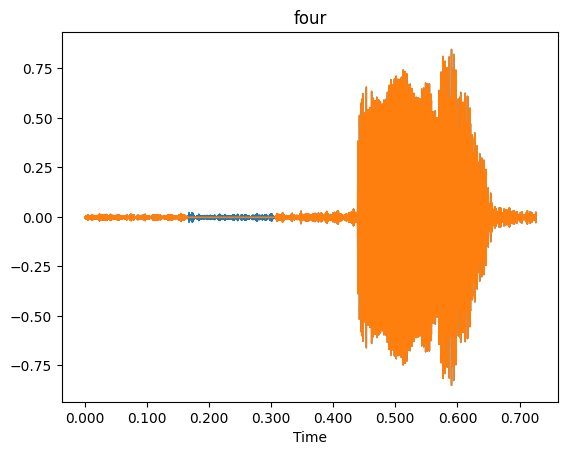

In [105]:
librosa.display.waveshow(x[0].flatten().numpy())
librosa.display.waveshow(s.flatten().numpy())
plt.title(labels[0])

Text(0.5, 1.0, 'four')

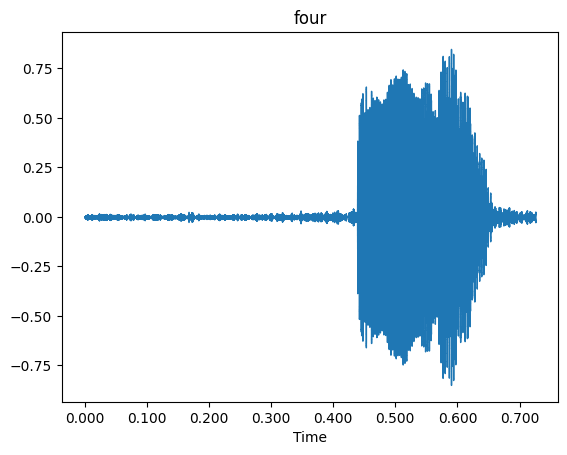

In [89]:

plt.title(labels[0])